# Home Credit Default Risk - Exploratory Data Analysis

**AI-Powered Credit Risk Intelligence Platform**

The question behind this notebook is not "what is in this dataset" but
**"what would a credit risk officer need to know before trusting a model built on it?"**

Four things, in order:

1. What are we actually predicting, and how rare is it?
2. What is the data quality, honestly - including the traps that are not missing values?
3. Which factors separate applicants who repay from applicants who default?
4. What does all of that imply for how the model must be built?

Every analysis here is imported from `src/data/eda_insights.py` rather than
written inline. That module is also what the Streamlit EDA tab calls, so the
notebook and the deployed app cannot drift apart.

In [1]:
import sys
from pathlib import Path

# Make the project importable when the notebook runs from notebooks/.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import pandas as pd
from IPython.display import Image, display

from src.data.eda_insights import (
    data_quality_scorecard, feature_categorisation, insight_age, insight_contract_type,
    insight_employment, insight_external_scores, insight_income, target_summary,
)
from src.data.loader import dataset_profile, load_dataset
from src.data.preprocessor import missing_report
from src.utils.config import settings

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
FIGURES = settings.figures_dir

## 1. Dataset overview

`application_train.csv` is the core table: one row per loan application, with the
outcome we are predicting. Two supplementary tables are joined in as
per-applicant aggregates - `bureau.csv` (credit history reported by external
bureaus) and `previous_application.csv` (prior applications to this lender).

The other four Home Credit tables are deliberately out of scope: roughly 1.9 GB
of monthly balance histories for a marginal gain, which would dominate build
time without changing the conclusions.

In [2]:
frame = load_dataset()
profile = dataset_profile(frame)
profile

03:01:14 | INFO    | credit_risk.data.loader      | Loading cached join from application_train_joined.parquet


{'n_rows': 307511,
 'n_columns': 155,
 'memory_mb': np.float64(637.8),
 'dtypes': {'float64': 98, 'int64': 41, 'object': 16},
 'duplicate_ids': 0,
 'columns_over_40pct_missing': 50,
 'columns_fully_populated': 55,
 'mean_missing_rate': 0.2165}

In [3]:
frame.head(5).iloc[:, :12]

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,Unaccompanied
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,Unaccompanied


### Feature categorisation

122 raw columns plus 33 joined aggregates is too many to reason about one at a
time. Grouping them by what they *measure* makes the shape of the dataset
visible - and immediately shows that the largest single block (property building
statistics) is also the least populated.

In [4]:
groups = feature_categorisation(frame)
pd.DataFrame([
    {"feature_group": name, "columns": info["count"], "examples": ", ".join(info["examples"][:3])}
    for name, info in groups.items()
])

,feature_group,columns,examples
0,property,47,"APARTMENTS_AVG, BASEMENTAREA_AVG, YEARS_BEGINE..."
1,credit_history_bureau,25,"AMT_REQ_CREDIT_BUREAU_HOUR, AMT_REQ_CREDIT_BUR..."
2,document,20,"FLAG_DOCUMENT_2, FLAG_DOCUMENT_3, FLAG_DOCUMENT_4"
3,demographic,18,"CODE_GENDER, CNT_CHILDREN, NAME_TYPE_SUITE"
4,repayment_behaviour,18,"OBS_30_CNT_SOCIAL_CIRCLE, DEF_30_CNT_SOCIAL_CI..."
5,financial,7,"NAME_CONTRACT_TYPE, FLAG_OWN_CAR, FLAG_OWN_REALTY"
6,other,6,"DAYS_REGISTRATION, DAYS_ID_PUBLISH, OWN_CAR_AGE"
7,contact,6,"FLAG_MOBIL, FLAG_EMP_PHONE, FLAG_WORK_PHONE"
8,employment,3,"DAYS_EMPLOYED, OCCUPATION_TYPE, ORGANIZATION_TYPE"
9,external_source,3,"EXT_SOURCE_1, EXT_SOURCE_2, EXT_SOURCE_3"


## 2. The target: an 8% event rate

This single number drives most of the modelling decisions that follow.

{'repaid': 282686,
 'defaulted': 24825,
 'default_rate': 0.0807,
 'imbalance_ratio': 11.39}

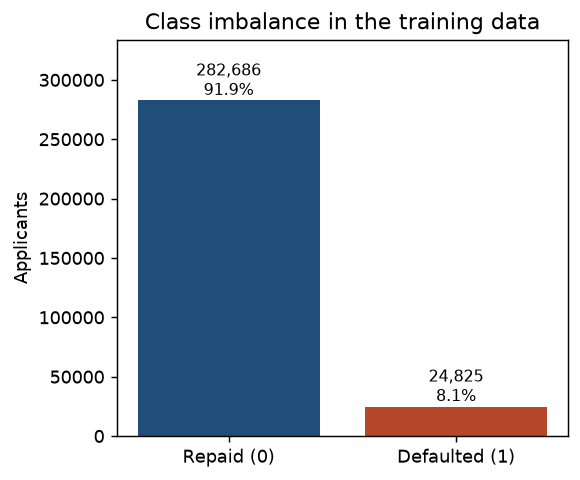

In [5]:
balance, figure = target_summary(frame)
display(balance)
display(Image(filename=str(FIGURES / figure)))

**Consequence.** At 8.07% positives (1 default per 12.4 applicants):

- **Accuracy is useless.** A model predicting "everyone repays" scores 91.9%.
- **ROC-AUC flatters.** PR-AUC is reported alongside it throughout this project.
- **Imbalance must be handled explicitly** - here with LightGBM
  `scale_pos_weight = 11.4`, not SMOTE (307k rows in 143 dimensions makes
  synthetic oversampling slow, and interpolating between categorical codes
  produces applicants that cannot exist).
- **Reweighting inflates the scores**, so calibration is not optional if the
  probability is going to be used for anything but ranking.

## 3. Data quality

### 3a. Missingness

49 of the 122 raw columns are more than 40% empty. Almost all of them belong to
the property block, and they are missing for a structural reason: the applicant
does not live in an apartment building the lender has statistics for.

In [6]:
report = missing_report(frame)
print(f"Columns over 40% missing: {(report['missing_rate'] > 0.4).sum()}")
print(f"Fully populated columns:  {(report['missing_rate'] == 0).sum()}")
report.head(12)[["missing_count", "missing_rate", "dtype"]].round(3)

Columns over 40% missing: 50
Fully populated columns:  55


,missing_count,missing_rate,dtype
COMMONAREA_MEDI,214865,0.699,float64
COMMONAREA_MODE,214865,0.699,float64
COMMONAREA_AVG,214865,0.699,float64
NONLIVINGAPARTMENTS_AVG,213514,0.694,float64
NONLIVINGAPARTMENTS_MODE,213514,0.694,float64
NONLIVINGAPARTMENTS_MEDI,213514,0.694,float64
FONDKAPREMONT_MODE,210295,0.684,object
LIVINGAPARTMENTS_AVG,210199,0.684,float64
LIVINGAPARTMENTS_MEDI,210199,0.684,float64
LIVINGAPARTMENTS_MODE,210199,0.684,float64


,feature_group,columns,mean_completeness,worst_completeness,columns_over_40pct_missing,fully_populated_columns
6,property,47,0.4213,0.3013,47,0
5,external_source,3,0.7453,0.4362,1,0
9,credit_history_bureau,25,0.8480,0.5980,1,0
3,employment,3,0.8955,0.6865,0,2
0,other,8,0.9175,0.3401,1,6
7,repayment_behaviour,18,0.9542,0.8897,0,0
2,demographic,18,0.9998,0.9958,0,16
1,financial,7,0.9999,0.9991,0,5
4,contact,6,1.0000,1.0000,0,6
8,document,20,1.0000,1.0000,0,20


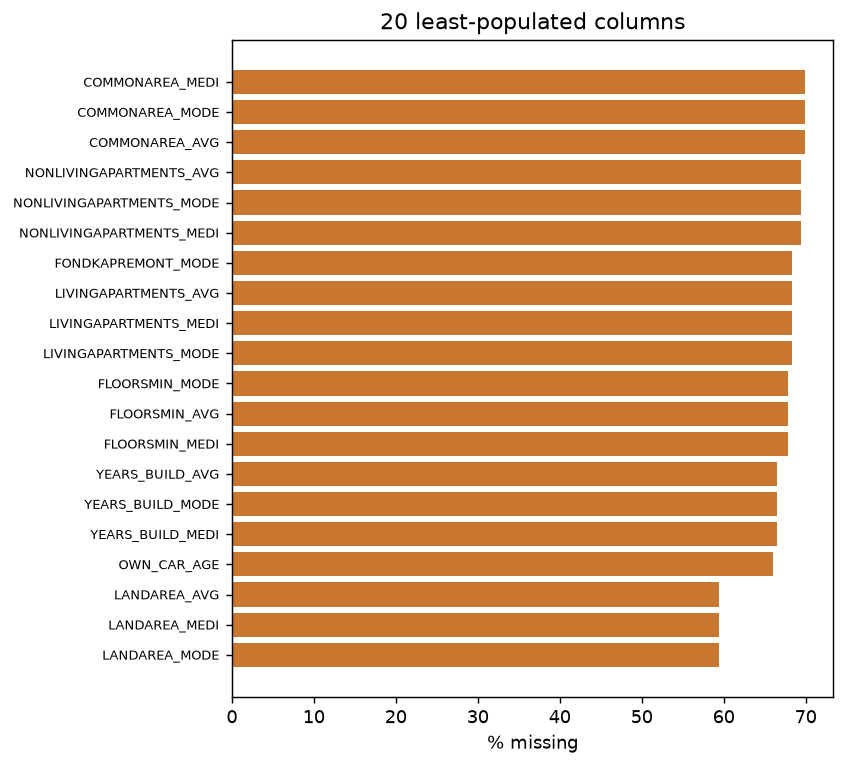

In [7]:
scorecard, missing_figure = data_quality_scorecard(frame)
display(scorecard)
display(Image(filename=str(FIGURES / missing_figure)))

### 3b. The traps that are not missing values

A null is easy: every profiler finds it. The expensive errors in this dataset are
values that are **present, valid-looking and wrong**.

In [8]:
for anomaly in scorecard.attrs["anomalies"]:
    print("-", anomaly)

- DAYS_EMPLOYED = 365243 on 55,374 rows (18.0%) - a 'not employed' sentinel, not 1000 years
- CODE_GENDER = 'XNA' on 4 rows - unknown, not a third class
- AMT_INCOME_TOTAL max is 117,000,000 against a median of 147,150 (795x) - a single extreme outlier that distorts every ratio
- OBS_30_CNT_SOCIAL_CIRCLE exceeds 100 on 1 rows - implausible


**`DAYS_EMPLOYED = 365243` is the one that matters.** It appears on 55,374 rows
(18.0%) and decodes to exactly 1000 years of employment. It is a sentinel for
"no employment record".

Left untouched it does three separate kinds of damage: the mean employment
length becomes meaningless, every ratio built on it inherits the corruption, and
any tree splitting on employment length gets a free, spurious separation.

Handled here in `CreditRiskPreprocessor.clean()`: the sentinel becomes `NaN` and
gains an explicit `IS_UNEMPLOYED` flag, so the signal survives without the lie.
The same repair is pinned into the Talk-to-Data semantic layer, so SQL answers
cannot reintroduce it.

In [9]:
sentinel = frame["DAYS_EMPLOYED"] == 365243
print(f"Sentinel rows: {sentinel.sum():,} ({sentinel.mean():.1%})")
print()
print("Who are they? Income type of the sentinel group:")
print(frame.loc[sentinel, "NAME_INCOME_TYPE"].value_counts().head())
print()
print(f"Naive mean 'employment years' if left raw: "
      f"{(-frame['DAYS_EMPLOYED'] / 365).mean():.1f} years")
print(f"Mean after repairing the sentinel:         "
      f"{(-frame.loc[~sentinel, 'DAYS_EMPLOYED'] / 365).mean():.1f} years")

Sentinel rows: 55,374 (18.0%)

Who are they? Income type of the sentinel group:
NAME_INCOME_TYPE
Pensioner     55352
Unemployed       22
Name: count, dtype: int64

Naive mean 'employment years' if left raw: -174.8 years
Mean after repairing the sentinel:         6.5 years


## 4. Business insights

Five insights, each with a chart, each with a consequence for the model or the
policy. The dashed line on every chart is the 8.07% portfolio average.

### Insight 1 - Income predicts default, but weakly

Higher income does lower default risk, and the gradient is real. But the spread
across the whole income range is roughly 3 percentage points, against a spread of
17 points across external credit-score deciles (Insight 4). Income is a weak
signal in this portfolio - which is exactly why a bank buys bureau scores.

,income_bracket,applicants,default_rate
0,<100k,63698,0.0820
1,100-150k,91591,0.0862
2,150-200k,64307,0.0845
3,200-300k,65176,0.0755
4,300k+,22739,0.0595


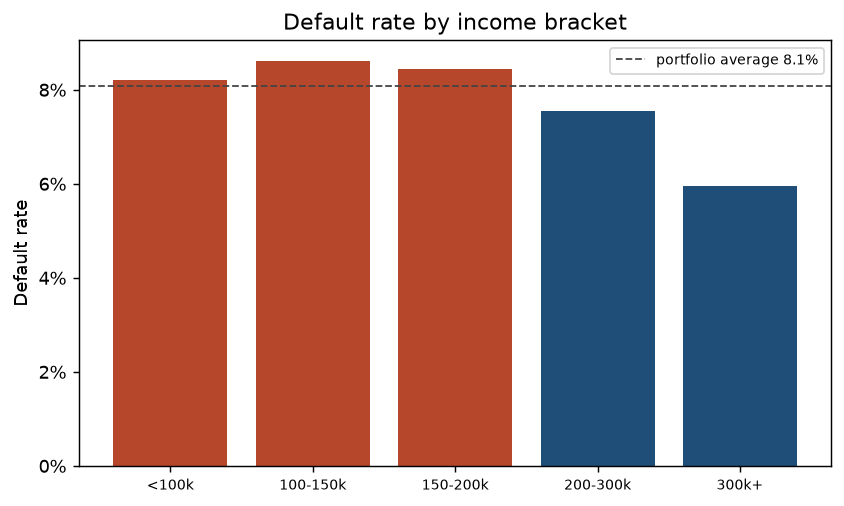

In [10]:
table, figure = insight_income(frame)
display(table)
display(Image(filename=str(FIGURES / figure)))

### Insight 2 - Cash loans default ~50% more often than revolving credit

8.35% against 5.48%. The average cash loan is also nearly double the size
(628k vs 324k), so the exposure gap is wider than the rate gap alone suggests -
which is precisely why the decision threshold in this project is cost-weighted
by loan amount rather than applied uniformly.

,NAME_CONTRACT_TYPE,applicants,default_rate,avg_credit
0,Cash loans,278232,0.0835,627965.7325
1,Revolving loans,29279,0.0548,324017.9822


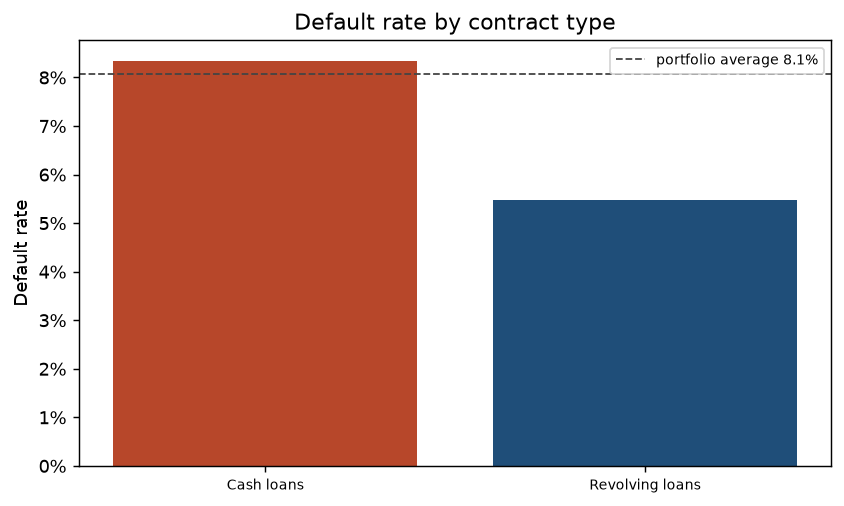

In [11]:
table, figure = insight_contract_type(frame)
display(table)
display(Image(filename=str(FIGURES / figure)))

### Insight 3 - Default risk falls monotonically with age

12.3% for under-25s against 4.9% for over-60s: a 2.5x spread, and one of the
cleanest monotone relationships in the dataset.

It is also the reason the Model Health & Fairness tab exists. Age is a protected
attribute under ECOA. The model may use it; the adverse-action notice may not
cite it. `reason_codes.py` suppresses it from the notice and reports the
suppression rather than hiding it.

,age_band,applicants,default_rate
0,<25,12150,0.1231
1,25-29,32850,0.1114
2,30-34,39439,0.1029
3,35-39,42860,0.0893
4,40-49,76543,0.0766
5,50-59,68074,0.0613
6,60+,35595,0.0492


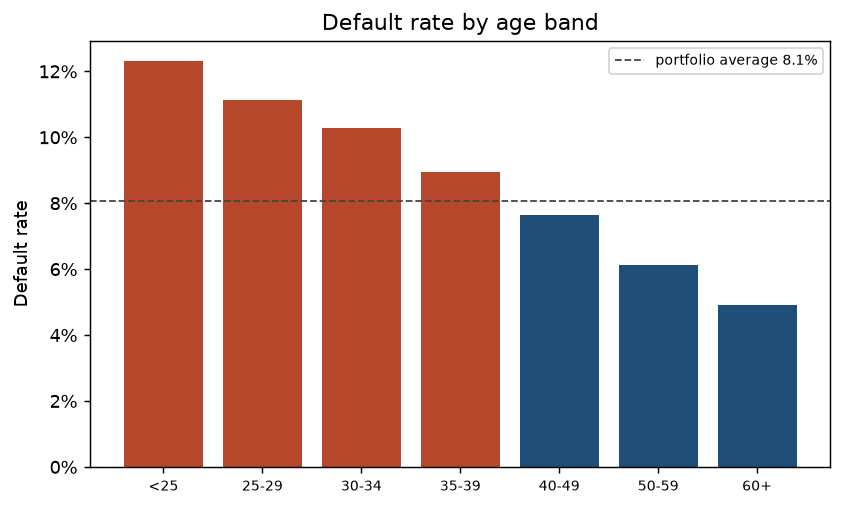

In [12]:
table, figure = insight_age(frame)
display(table)
display(Image(filename=str(FIGURES / figure)))

### Insight 4 - External credit scores are the strongest signal in the dataset

All three `EXT_SOURCE` columns separate the population by roughly **6x** between
their best and worst deciles. Nothing else in the application form comes close.

The catch is coverage: `EXT_SOURCE_1` is present for only 44% of applicants. So
the feature engineering builds `EXT_SOURCE_MEAN` (averaging whichever scores
exist), `EXT_SOURCE_MIN`, `EXT_SOURCE_MAX` and `EXT_SOURCE_COUNT` - because
*how many* bureaus will score an applicant is itself informative.

,score,coverage,correlation_with_target,default_rate_worst_decile,default_rate_best_decile,risk_ratio
0,EXT_SOURCE_1,0.4362,-0.1553,0.1756,0.0257,6.83
1,EXT_SOURCE_2,0.9979,-0.1605,0.1835,0.0297,6.17
2,EXT_SOURCE_3,0.8017,-0.1789,0.2001,0.0323,6.20


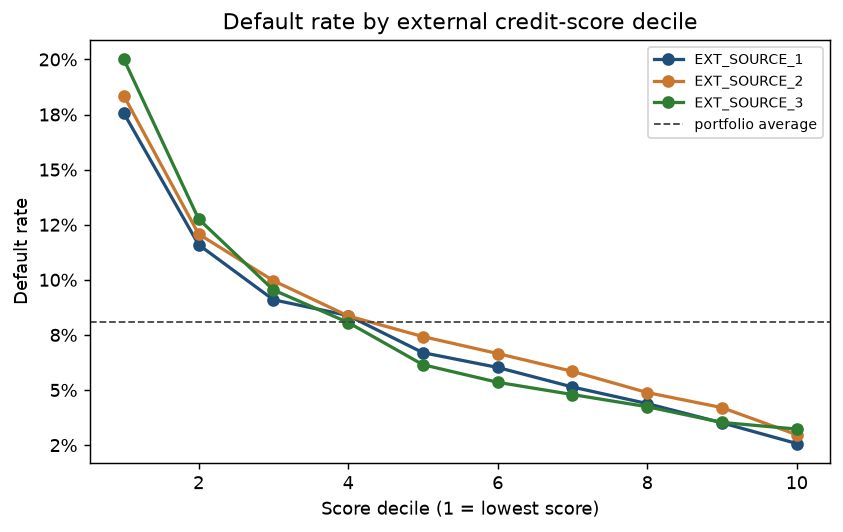

In [13]:
table, figure = insight_external_scores(frame)
display(table)
display(Image(filename=str(FIGURES / figure)))

### Insight 5 - Employment length, and why the sentinel must be split out

Among employed applicants the trend is clean: 11.0% at under a year, 5.2% past
ten years.

The striking part is the sentinel group. Those 55,374 "not employed" applicants
default at **5.4%** - *below* the employed average of 8.7% - because 99.96% of
them are pensioners, who have stable income and no employment record.

Bin them into the "10 years+" bucket and the number moves the wrong way for the
wrong reason. Drop them and 18% of the portfolio disappears. Split them out and
they are one of the safer segments in the book. This is the difference between
a data-quality note and an actual finding.

,band,applicants,default_rate
0,<1y,27904,0.1098
1,1-3y,61489,0.1107
2,3-5y,46874,0.0967
3,5-10y,64890,0.0737
4,10y+,50980,0.0519
5,Not employed (sentinel),55374,0.0540


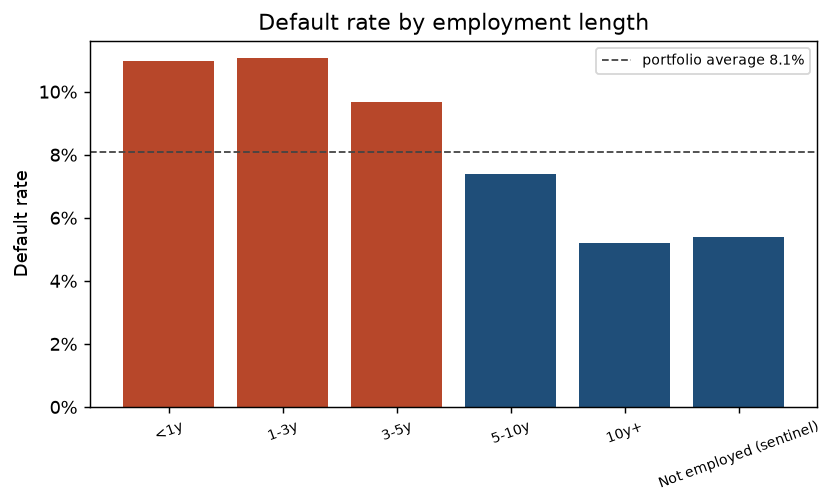

In [14]:
table, figure = insight_employment(frame)
display(table)
display(Image(filename=str(FIGURES / figure)))

## 5. What the EDA dictates about the model

| Finding | Consequence |
|---|---|
| 8.07% positive rate | `scale_pos_weight = 11.4`; report PR-AUC alongside ROC-AUC; calibrate afterwards |
| 49 columns >40% missing | Keep NaN and let LightGBM learn a split direction - missingness is itself predictive |
| `_AVG` / `_MODE` / `_MEDI` triplets | Keep `_AVG`, drop ~30 near-duplicate columns |
| `DAYS_EMPLOYED = 365243` | Repair to NaN + `IS_UNEMPLOYED`; pin the fix into the SQL semantic layer too |
| Income outlier at 117M (795x median) | Clip at the 99.95th percentile, learned at fit time and replayed at inference |
| External scores dominate but are sparse | Engineer mean / min / max / count / disagreement across the three |
| Age and gender are predictive | Model may use them; the adverse-action notice may not cite them - suppress and report |
| Cash loans are larger *and* riskier | Cost-weight the decision threshold by `AMT_CREDIT`, not by count |

Next: `src/ml/train.py` builds the model these findings imply, and
`src/monitoring/fairness.py` measures the group gaps this section predicts.